## **Análise de dados - Portal da Transparência**

In [25]:
caminho_dados = "/content/drive/MyDrive/AND/2025_Viagem.csv"
caminho_saida_tab = "/content/drive/MyDrive/AND/output/tabela_2025.xlsx"
caminho_saida_graf = "/content/drive/MyDrive/AND/output/grafico_2025.png"

In [26]:
import pandas as pnd

pnd.set_option("display.max_columns", None)
pnd.set_option("display.float_format", '{:.2f}'.format)

#Lendo os dados
df_viagens = pnd.read_csv(caminho_dados, encoding = "Windows-1252", sep = ";", decimal = ",")

#Criando nova coluna de despesas
df_viagens["Despesas"] = df_viagens["Valor diárias"] + df_viagens["Valor passagens"] + df_viagens["Valor outros gastos"]

#Ajustando valores nulos na colunda de cargo
df_viagens['Cargo'] = df_viagens['Cargo'].fillna("NÃO IDENTIFICADO")

#Convertendo colunas de datas
df_viagens["Período - Data de início"] = pnd.to_datetime(df_viagens["Período - Data de início"], format="%d/%m/%Y")
df_viagens["Período - Data de fim"] = pnd.to_datetime(df_viagens["Período - Data de fim"], format="%d/%m/%Y")

#Criando novas colunas de datas
df_viagens['Mês da viagem'] = df_viagens['Período - Data de início'].dt.month_name()
df_viagens ["Dias de viagem"]=(df_viagens['Período - Data de fim'] - df_viagens['Período - Data de início']).dt.days


In [27]:
#Criando tabela consolidada
df_v_consolidado = (df_viagens
    .groupby("Cargo")
    .agg(
        despesa_med=("Despesas", "mean"),
        duracao_med=("Dias de viagem", "mean"),
        despesas_tot=("Despesas", "sum"),
        destinos_freq=("Destinos", pnd.Series.mode),
        n_viagens=("Nome", "count")
        )
    .reset_index()
    .sort_values(by="despesas_tot", ascending=False))

#Filtrando tabela consolidada por cargos relevantes (> 1% das viagens)
df_cargos = df_viagens['Cargo'].value_counts(normalize=True).reset_index()
cargos_relev = df_cargos.loc[df_cargos["proportion"] > 0.01, 'Cargo']
filtro = df_v_consolidado["Cargo"].isin(cargos_relev)

#Chegando na tabela final - consolidada e filtrada!
df_final = df_v_consolidado[filtro].sort_values(by='n_viagens', ascending=False)

#Salvando a tabela final
df_final.to_excel(caminho_saida_tab, index=False)

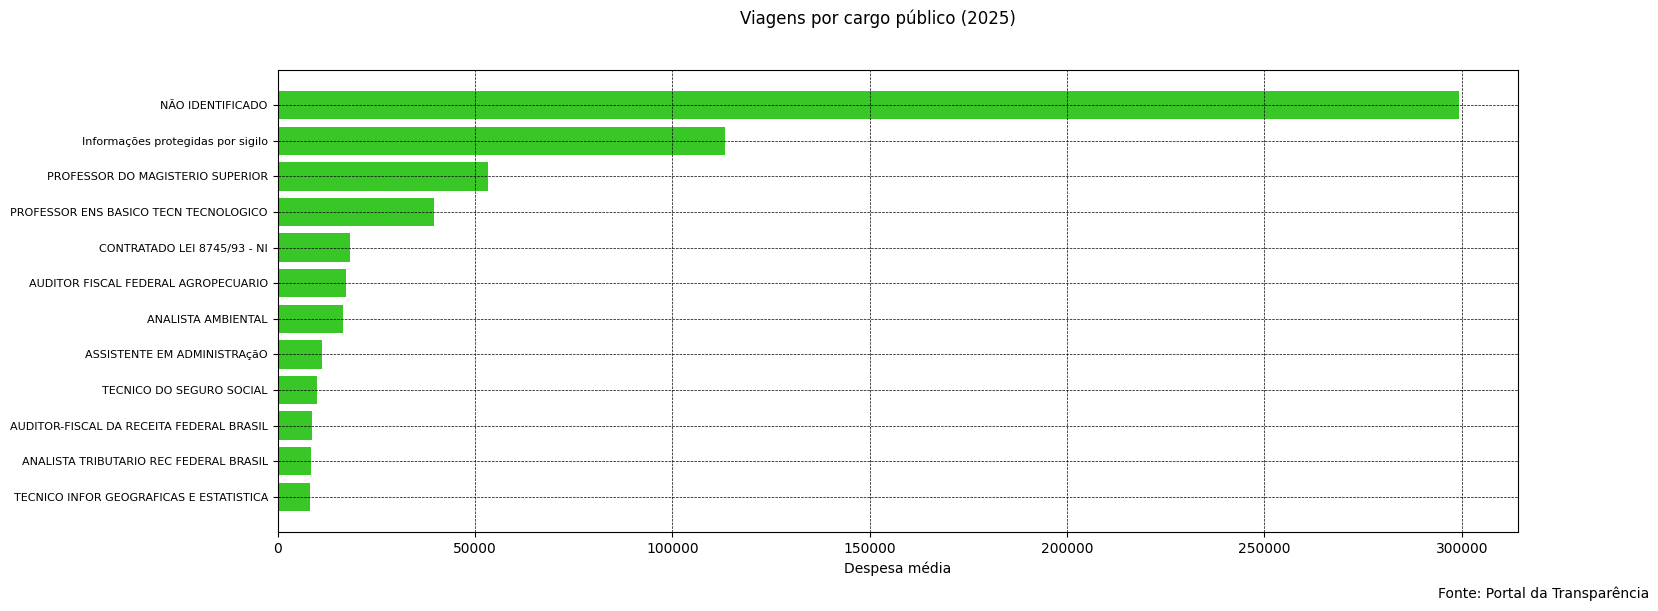

In [28]:
import matplotlib.pyplot as plt

#Criando a figura
fig, ax = plt.subplots(figsize=(16, 6))

#Plotando o gráfico
ax.barh(df_final['Cargo'], df_final['n_viagens'], color='#38c726')
ax.invert_yaxis()

#Ajustando o gráfico
ax.set_facecolor('#ffffff')
fig.suptitle('Viagens por cargo público (2025)')
plt.figtext(0.85, 0.00, 'Fonte: Portal da Transparência')
plt.grid(color='black', linestyle="--", linewidth=0.5)
plt.yticks(fontsize=8)
plt.xlabel('Despesa média')

#Salvando o gráfico
plt.savefig(caminho_saida_graf, bbox_inches='tight')